# Wikipedia Network Analysis: Community Detection

In this notebook we will use the **Louvain algorrithm** to detect communities in the wikipedia network and compare them with the ground-truth categories to check if semantic comunities are also structured in the network. We chose the Louvain algorithm because it's one of the most used and it's efficient for large networks, making it suitable for our Wikipedia dataset.

We will procede with the following steps:
- Extract the ground-truth categories from the dataset
- Use the Louvain algorithm to detect communities in the Wikipedia network
- Tune the resolution parameter to optimize different metrics
- Compare the detected communities with the ground-truth categories using numeric metrics and visual representations

## Import Libraries and Load Data

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import unquote
from collections import Counter
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

np.random.seed(22)

In [2]:
#Load data
df_articles = pd.read_csv('./data/datasets/articles.tsv', sep='\t', skiprows=12, names=['article'])
df_articles["article"] = df_articles["article"].apply(lambda x: unquote(x))

df_links = pd.read_csv('./data/datasets/links.tsv', sep='\t', skiprows=12, names=['source', 'target'])
df_links["source"] = df_links["source"].apply(lambda x: unquote(x))
df_links["target"] = df_links["target"].apply(lambda x: unquote(x))

df_categories = pd.read_csv('./data/datasets/categories.tsv', sep='\t', skiprows=12, names=['article', 'category'])
df_categories["article"] = df_categories["article"].apply(lambda x: unquote(x))

#create graph
G = nx.DiGraph()
G.add_nodes_from(df_articles["article"])
G.add_edges_from(zip(df_links["source"], df_links["target"]))

#extract largest weakly connected component 
weakly_connected_components = sorted(list(nx.weakly_connected_components(G)), reverse=True, key=len)
core_nodes = weakly_connected_components[0]
C = G.subgraph(core_nodes)

print(f"Graph: {C.number_of_nodes()} nodes, {C.number_of_edges()} edges")

Graph: 4589 nodes, 119879 edges


## Extract Ground Truth Categories

Let's extract the ground truth categories from the dataset, where each article is associated with one categories organized in a hierarchical tree structure (e.g. Tyrannosaurus: subject.Science.Biology.Dinosaurs).
To simplify the task, we use only the top-level category (e.g. Science) as the ground truth for evaluating community detection in our analysis.
Using lower-level (more specific) categories result in an excessively large number of categories, making the analysis more complex and less interpretable.

In [3]:
#parsing categories info to get k-level category
def get_k_category(category_str,k):
        categories = category_str.split('.')[1:]  # Skip "Subject" prefix
        if k==0:
            return categories[0] # top-level category
        elif len(categories) > k:
            return categories[k]
        else:   
            return get_k_category(category_str, k-1)

# extracting top category
df_categories['main_category'] = df_categories['category'].apply(get_k_category, k=0)
# deleting duplicates
df_categories= df_categories.drop_duplicates(subset='article', keep='first')
# considering only articles in largest component
df_categories = df_categories[df_categories['article'].isin(C.nodes())].copy()

#create true labels for evaluation
article_to_category = dict(zip(df_categories['article'], df_categories['main_category']))
true_labels = [article_to_category[node] for node in C.nodes()]


#prints
print("Number of categories:", df_categories['main_category'].nunique())
counts_categories=df_categories['main_category'].value_counts()
perc_categories = counts_categories / C.number_of_nodes() * 100
for category, count in counts_categories.items():
    print(f"{category}: {count} articles ({(count*100/C.number_of_nodes()):.2f}%)")

Number of categories: 15
Science: 1033 articles (22.51%)
Geography: 952 articles (20.75%)
People: 584 articles (12.73%)
History: 508 articles (11.07%)
Everyday_life: 350 articles (7.63%)
Design_and_Technology: 230 articles (5.01%)
Citizenship: 206 articles (4.49%)
Language_and_literature: 181 articles (3.94%)
Religion: 116 articles (2.53%)
Music: 95 articles (2.07%)
Countries: 92 articles (2.00%)
Business_Studies: 85 articles (1.85%)
IT: 77 articles (1.68%)
Mathematics: 43 articles (0.94%)
Art: 37 articles (0.81%)


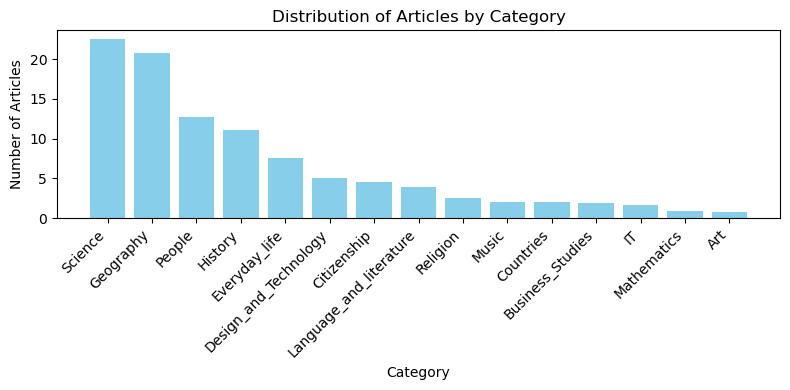

In [4]:
#plot categories distribution
plt.figure(figsize=(8, 4))
plt.bar(counts_categories.index, perc_categories, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.title('Distribution of Articles by Category')
plt.tight_layout()
plt.show()

We can observe that the top-level Wikipedia categories (as of 2007) are quite arbitrary. They do not form a consistent ontology but were instead defined based on the interests of the contributors. There are two distinct macro-groups, "Countries" and "Geography", despite their significant overlap. There is also a category "Everyday Life", which includes a a lot of miscellaneous articles.
Finally, the distribution of articles across categories is highly unbalanced: the top three categories account for 50% of all articles, while the bottom three represent less than 4%.

## Hyperparameter Tuning: modularity
Let's tune the **resolution** hyperparameters of the Louvain algorithm to maximize the **modularity** of the detected communities. 
The resolution parameter controls the size of the communities, with higher values leading to smaller communities and lower values leading to larger communities.

The **modularity** is a useful metric to evaluate the quality of a partition into communities. It measures the density of links inside communities compared to links between communities. It used in the Louvain algorithm to optimize the community structure.

For directed networks, the modularity is defined as: 
$$Q = \sum_{C} [ \frac{L_C}{L} - \frac{k^{out}_C k^{in}_C}{L^2}]$$

Where:
- $L_C$ is the number of links within community $C$
- $k^{out}_C $ is the sum of the out degrees of all nodes in community $C$
- $k^{in}_C$ is the sum of the in degrees of all nodes in community $C$
- $L$ is the total number of links in the network



In [5]:
resolutions = np.arange(0.5, 2, 0.1) 
mod_scores = []
for res in resolutions:
    communities = nx.community.louvain_communities(C, resolution=res, seed=22)
    modularity = nx.community.modularity(C, communities)
    mod_scores.append(modularity)

best_mod_idx=np.argmax(mod_scores)
best_resolution_mod=resolutions[best_mod_idx]


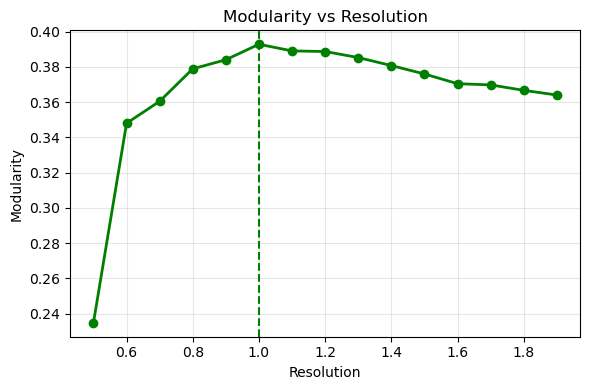

Best resolution for NMI: 1.00 (NMI = 0.3928)


In [6]:
#plot
plt.figure(figsize=(6, 4))
plt.plot(resolutions, mod_scores, 'o-', color='green', linewidth=2, markersize=6)
plt.axvline(best_resolution_mod, color='green', linestyle='--')
plt.xlabel('Resolution')
plt.ylabel('Modularity')
plt.title('Modularity vs Resolution')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best resolution for NMI: {best_resolution_mod:.2f} (NMI = {mod_scores[best_mod_idx]:.4f})")

## Louvain Community Detection 
Let's apply the Louvain community detection algorithm with the optimal resolution found in the previous step. We will then analyze the detected communities and results.

In [7]:
#apply Louvain community detection
communities = nx.community.louvain_communities(C, resolution=best_resolution_mod, seed=22)

print(f"Number of detected communities: {len(communities)}")
print("Community sizes:")
for i, comm in enumerate(communities):
    print(f"  Community {i}: {len(comm)} nodes ({len(comm)/C.number_of_nodes()*100:.1f}%)")

#calculate modularity
modularity = nx.community.modularity(C, communities)
print(f"\nModularity: {modularity:.4f}")

Number of detected communities: 7
Community sizes:
  Community 0: 611 nodes (13.3%)
  Community 1: 394 nodes (8.6%)
  Community 2: 597 nodes (13.0%)
  Community 3: 701 nodes (15.3%)
  Community 4: 849 nodes (18.5%)
  Community 5: 625 nodes (13.6%)
  Community 6: 812 nodes (17.7%)

Modularity: 0.3928


## Compare Communities with Ground Truth
We will compare the detected communities with the ground truth categories using two metrics:
- **Adjusted Rand Index (ARI)**: Measures the similarity between two clusterings, adjusted for chance. Values range from -1 to 1, where 1 indicates perfect agreement. 
- **Normalized Mutual Information (NMI)**: Measures the mutual information between the two clusterings, normalized to a 0-1 scale, where 1 indicates perfect agreement.

In [8]:
#supporting function to create predicted labels 
def get_pred_labels(communities, C):
    node_to_community = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_community[node] = i
    return [node_to_community[node] for node in C.nodes()]

pred_labels = get_pred_labels(communities, C)

#metrics
ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)

print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

Adjusted Rand Index (ARI): 0.177
Normalized Mutual Information (NMI): 0.221


### Results
Given the result we can conclude that the Louvain algorithm was able to detect communities with moderate good modularity, meaning that the detected communities are somewhat cohesive and quite well structured within the network. But ARI and NMI scores indicate a weak agreement with ground truth, suggesting that the detected communities do not align well with the semantic categories of the articles. This could be due to the arbitrary nature of the categories or to a poor representation in the network structure.

## Visualization: Heatmap
Let's create an heatmap to show the alignment between detected communities and ground truth categories. Each cell represents the proportion of articles from a specific category that belong to each detected community.

In [9]:
#support function for creating and plotting heatmap
def plot_heatmap(pred_labels, true_labels,figsize=(12, 8),norm="index"):
    # Create confusion matrix
    conf_matrix = pd.crosstab(pd.Series(true_labels, name="True"),
                              pd.Series(pred_labels, name="Pred"), 
                              normalize=norm
                        )
    plt.figure(figsize=figsize)
    sns.heatmap(conf_matrix, cmap='Blues',annot=True, fmt='.2f',
                xticklabels=[f"Comm {c}" for c in conf_matrix.columns],
                yticklabels=conf_matrix.index,
                cbar_kws={'label': 'Proportion'})
    plt.title("Community-Category Alignment Heatmap")
    plt.xlabel('Detected Communities')
    plt.ylabel('Ground Truth Categories')
    plt.tight_layout()
    plt.show()

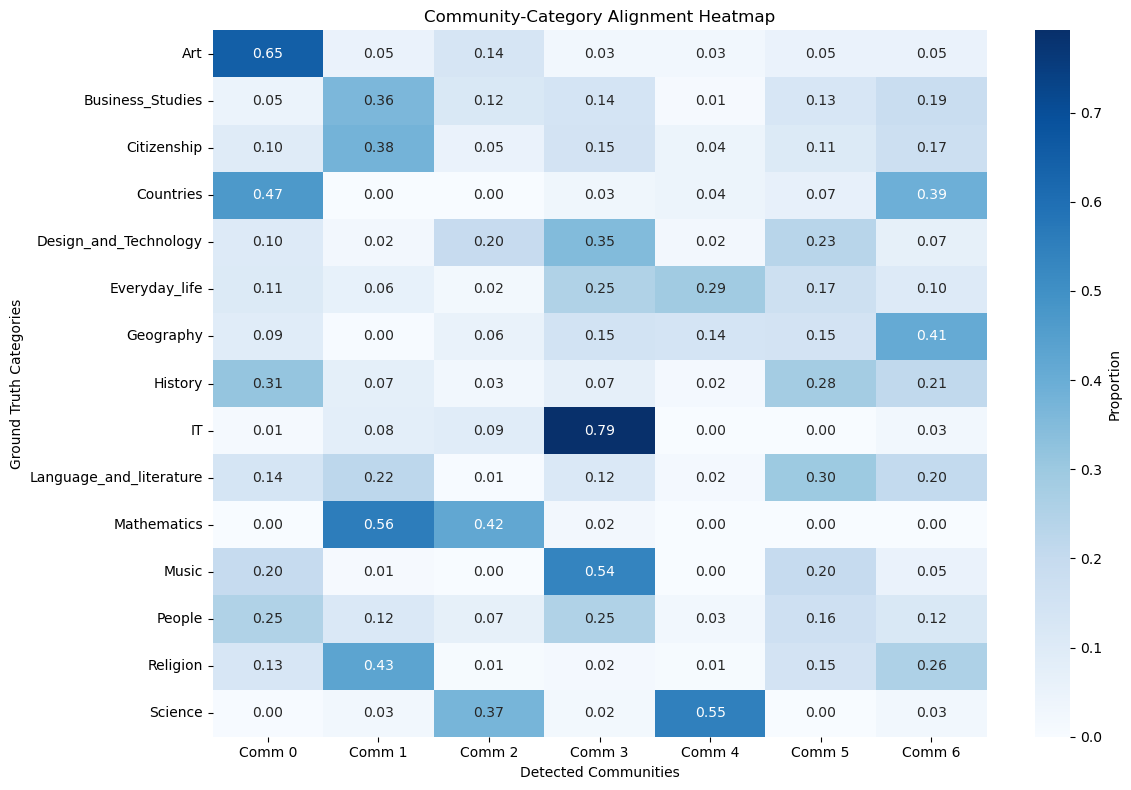

In [10]:
plot_heatmap(pred_labels, true_labels)

### Observations:

As previously highlighted through similarity measures, the result of the community detection is not fully satisfactory: there are fewer communities than categories, and the articles are more evenly distributed. This leads to the aggregation of multiple semantic categories into a single community. Moreover, several categories are notably small (Art: 37 articles, Mathematics: 43 articles, Business Studies: 85 articles), which may contribute to clustering instability.

**Strong Alignment**
- Art: Primarily in Community 0
- IT : Primarily in Community 3
- Geography: Primarily in Community 6
- Music: Primarily in Community 3

**Moderate Alignment**

- Countries: Split between Communities 0 and 6
- Mathematics : Split between Communities 1 and 2
- Science: Split between Communities 2 and 4

**Poor Alignment**
The other categories are poorly aligned with the detected communities, articles are spreaded across multiple communities.


**Coherent Communities:**
We can identify some semantic coherent communities based on the categories:
- Community 0: arts and humanities (Art, History, Language_and_Literature)
- Community 2: STEM fields (Science, Mathematics, Design_and_Technology)
- Community 5: humanities (Design_and_Technology,History,Language_and_Literature, Music)
- Community 6: geographic (Geography, Countries)

**Incoherent Communities**
- Community 3: IT mixed with Music and Design_and_Technology
- Community 1: Mathematics combined with Religion, Business_Studies and Citizenship



## Hyperparameter Tuning: ARI and NMI
To get better results with semantic categories, we can try to tune the **resolution** hyperparameters to maximize the **Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)** of the detected communities.

In [11]:
resolutions = np.arange(0.5, 2, 0.1)
ari_scores = []
nmi_scores = []

for res in resolutions:
    communities_temp = nx.community.louvain_communities(C, resolution=res, seed=22)
    pred_labels_temp = get_pred_labels(communities_temp, C)
    
    # Calculate metrics
    ari = adjusted_rand_score(true_labels, pred_labels_temp)
    nmi = normalized_mutual_info_score(true_labels, pred_labels_temp)
    ari_scores.append(ari)
    nmi_scores.append(nmi)

# Find optimal resolutions
best_ari_idx = np.argmax(ari_scores)
best_nmi_idx = np.argmax(nmi_scores)
best_resolution_ari = resolutions[best_ari_idx]
best_resolution_nmi = resolutions[best_nmi_idx]

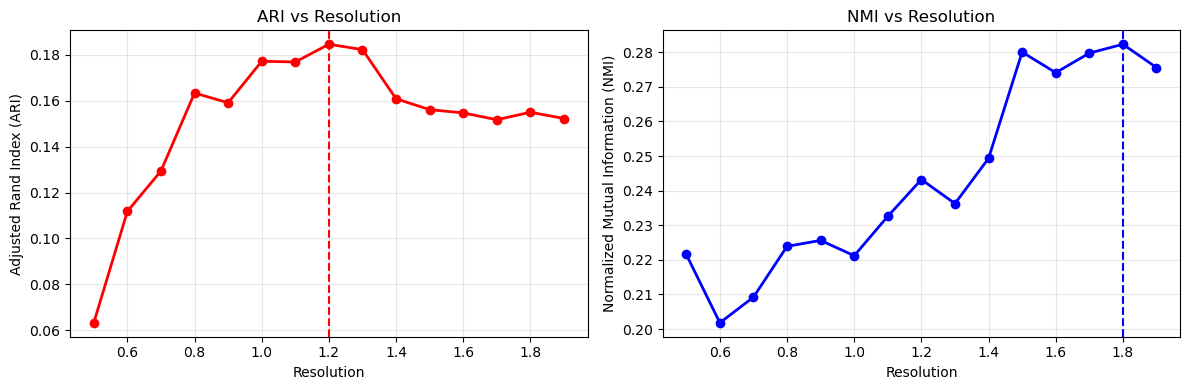

Best resolution for ARI: 1.20 (ARI = 0.1847)
Best resolution for NMI: 1.80 (NMI = 0.2823)


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ARI plot
ax1.plot(resolutions, ari_scores, 'o-', color='red', linewidth=2, markersize=6)
ax1.axvline(best_resolution_ari, color='red', linestyle='--')
ax1.set_xlabel('Resolution')
ax1.set_ylabel('Adjusted Rand Index (ARI)')
ax1.set_title('ARI vs Resolution')
ax1.grid(True, alpha=0.3)

# NMI plot
ax2.plot(resolutions, nmi_scores, 'o-', color='blue', linewidth=2, markersize=6)
ax2.axvline(best_resolution_nmi, color='blue', linestyle='--')
ax2.set_xlabel('Resolution')
ax2.set_ylabel('Normalized Mutual Information (NMI)')
ax2.set_title('NMI vs Resolution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best resolution for ARI: {best_resolution_ari:.2f} (ARI = {ari_scores[best_ari_idx]:.4f})")
print(f"Best resolution for NMI: {best_resolution_nmi:.2f} (NMI = {nmi_scores[best_nmi_idx]:.4f})")

### Optimal resolution for ARI

In [13]:
#apply Louvain community detection
communities = nx.community.louvain_communities(C, resolution=best_resolution_ari, seed=22)
pred_labels = get_pred_labels(communities, C)

#calculate metrics
ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)
modularity = nx.community.modularity(C, communities)

#prints
print(f"Number of detected communities: {len(communities)}")
print("Community sizes:")
for i, comm in enumerate(communities):
    print(f"  Community {i}: {len(comm)} nodes ({len(comm)/C.number_of_nodes()*100:.1f}%)")

print(f"\nModularity: {modularity:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

Number of detected communities: 11
Community sizes:
  Community 0: 376 nodes (8.2%)
  Community 1: 318 nodes (6.9%)
  Community 2: 591 nodes (12.9%)
  Community 3: 583 nodes (12.7%)
  Community 4: 892 nodes (19.4%)
  Community 5: 526 nodes (11.5%)
  Community 6: 539 nodes (11.7%)
  Community 7: 20 nodes (0.4%)
  Community 8: 452 nodes (9.8%)
  Community 9: 188 nodes (4.1%)
  Community 10: 104 nodes (2.3%)

Modularity: 0.3887
Adjusted Rand Index (ARI): 0.185
Normalized Mutual Information (NMI): 0.243


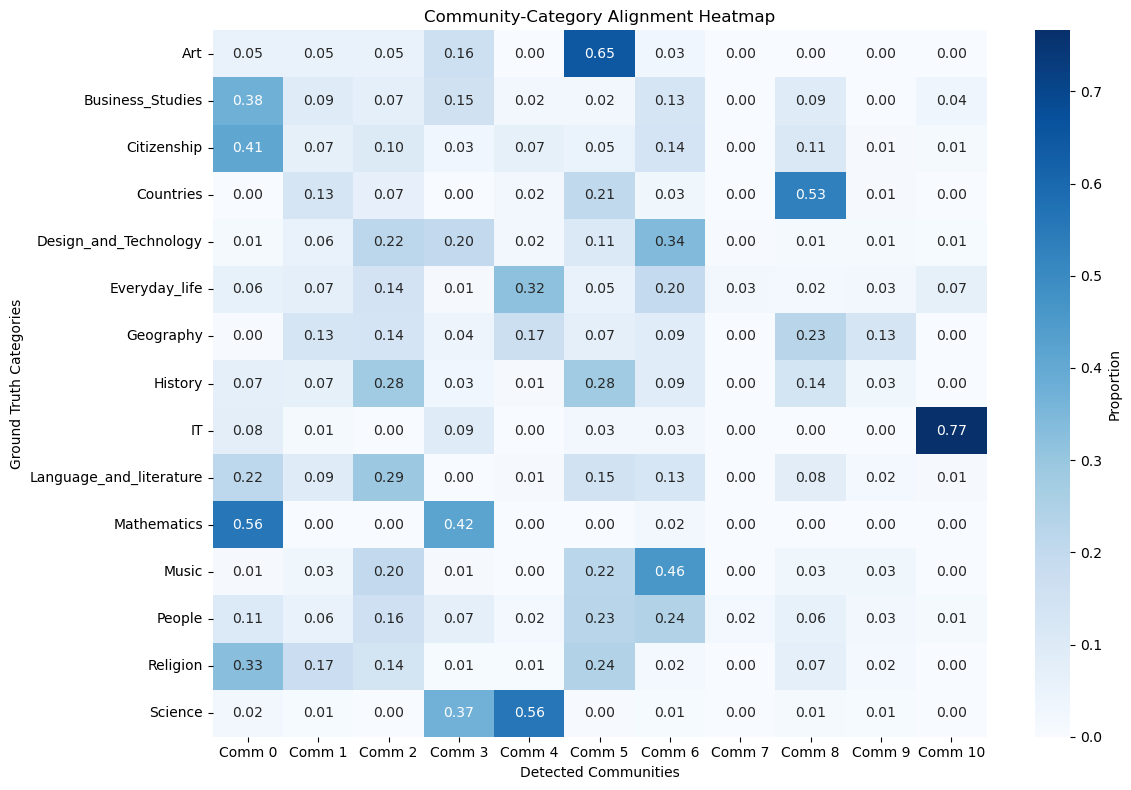

In [14]:
plot_heatmap(pred_labels, true_labels)

### Observations:
The optimal resolution for ARI is 1.20, which leads to more communities and a non-uniform distribution.
Although a higher ARI was achieved, the resulting communities do not appear to be semantically improved: the previously identified communities remain unchanged, and the additional ones do not refine the existing division but rather seems not meaningful.

**Strong Alignment**
- Art: Primarily in Community 5
- IT : Primarily in Community 10 (Better separation)
- Music: Primarily in Community 6
- Countries: Primarily in Community 8

**Moderate Alignment**
- Mathematics : Split between Communities 0 and 3
- Science: Split between Communities 3 and 4

**Poor Alignment**
The other categories are poorly aligned with the detected communities, articles are spreaded across multiple communities.

**Coherent Communities:**
We can identify some semantic coherent communities based on the categories:
- Community 2: humanities (Design_and_Technology,History,Language_and_Literature, Music)
- Community 3: STEM fields (Science, Mathematics, Design_and_Technology)
- Community 5: arts and humanities (Art, History, Language_and_Literature)
- Community 8: geographic (Geography, Countries)

**Incoherent Communities**
- Community 0: Mathematics combined with Religion, Business_Studies and Citizenship
- Community 1, 9: Seems to contain a mix of articles from different categories, leading to incoherent communities.
- Community 7: Really small comunity with only 20 nodes 



### Optimal Resolution for NMI

In [15]:
#apply Louvain community detection
communities = nx.community.louvain_communities(C, resolution=best_resolution_nmi, seed=22)
pred_labels = get_pred_labels(communities, C)

#calculate metrics
ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)
modularity = nx.community.modularity(C, communities)

#prints
print(f"Number of detected communities: {len(communities)}")
print("Community sizes:")
for i, comm in enumerate(communities):
    print(f"  Community {i}: {len(comm)} nodes ({len(comm)/C.number_of_nodes()*100:.1f}%)")

print(f"\nModularity: {modularity:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

Number of detected communities: 20
Community sizes:
  Community 0: 40 nodes (0.9%)
  Community 1: 272 nodes (5.9%)
  Community 2: 152 nodes (3.3%)
  Community 3: 76 nodes (1.7%)
  Community 4: 497 nodes (10.8%)
  Community 5: 306 nodes (6.7%)
  Community 6: 235 nodes (5.1%)
  Community 7: 233 nodes (5.1%)
  Community 8: 200 nodes (4.4%)
  Community 9: 224 nodes (4.9%)
  Community 10: 184 nodes (4.0%)
  Community 11: 391 nodes (8.5%)
  Community 12: 497 nodes (10.8%)
  Community 13: 196 nodes (4.3%)
  Community 14: 185 nodes (4.0%)
  Community 15: 248 nodes (5.4%)
  Community 16: 34 nodes (0.7%)
  Community 17: 287 nodes (6.3%)
  Community 18: 134 nodes (2.9%)
  Community 19: 198 nodes (4.3%)

Modularity: 0.3667
Adjusted Rand Index (ARI): 0.155
Normalized Mutual Information (NMI): 0.282


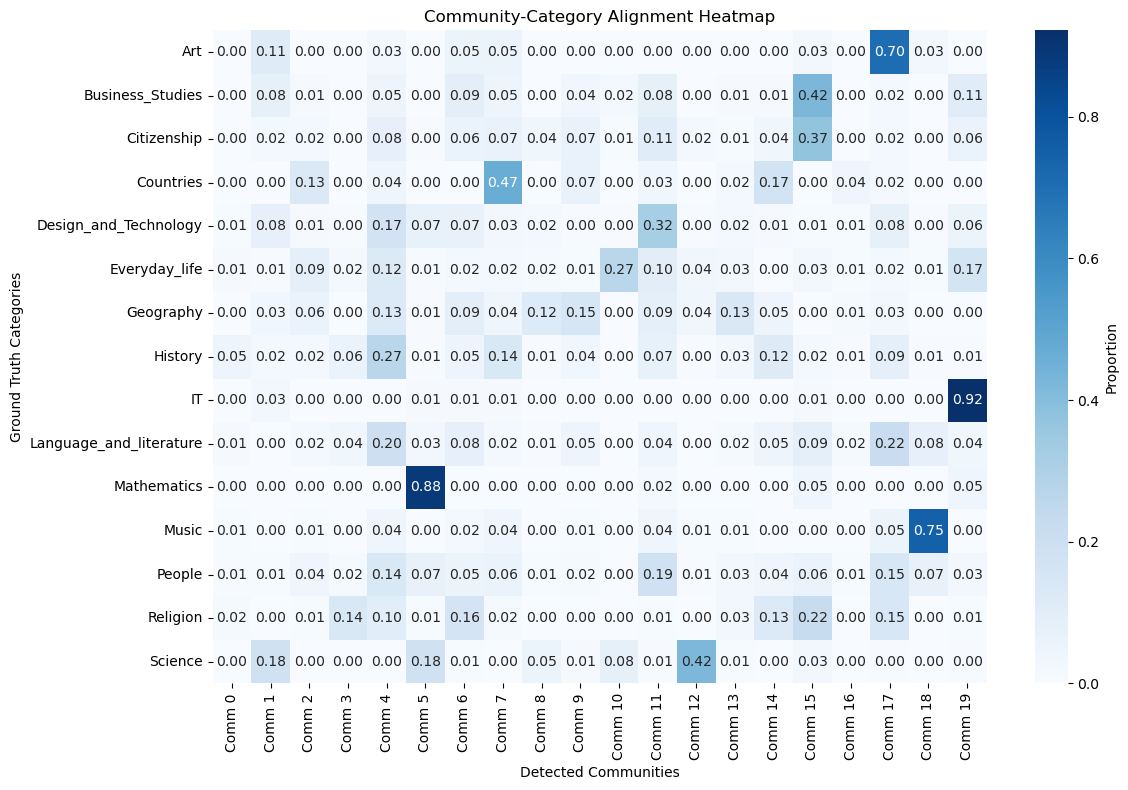

In [16]:
plot_heatmap(pred_labels, true_labels)

### Observations:

The optimal resolution for NMI is 1.8, which results in much more smaller communities. In fact, NMI continues to increase with higher resolution, but the communities become too small and fragmented, leading to **overclustering**.

In this case, the addition of new communities allowed for better identification of certain categories, reinforcing the alignment of those previously identified and separating categories that were previously grouped into larger communities. However, many categories are now spread across numerous communities, possibly due to loosely connected subcategories, and the number of meaningless communities has increased.


**Strong Alignment**

- Mathematics: Primarily in Community 5
- Countries: Primarily in Community 7
- Science: Primarily in Community 12
- Business Studies: Primarily in Community 15
- Citizenship: Primarily in Community 15
- Art: Primarily in Community 17
- Music: Primarily in Community 18
- IT : Primarily in Community 19

**Poor Alignment**: Those categories are poorly aligned with the detected communities, articles are spreaded across multiple communities.
- Design_and_Technology
- Everyday Life
- Geography
- History
- Language_and_Literature
- People
- Religion

**Coherent Communities:**
We can identify some semantic coherent communities based on the categories:
- Community 4: humanities (Design_and_Technology,History,Language_and_Literature, Religion)
- Community 5: STEM fields (Science, Mathematics)
- Community 15: Business_Studies, Citizenship and Religion (now separated from Mathematics)
- Community 17: arts and humanities (Art, History, Language_and_Literature)

**Incoherent Communities**
- A lot of miscellaneous communities with inchoerent meaning.



## Summary and Conclusions
This analysis examined the effectiveness of the Louvain algorithm for detecting communities in the Wikipedia network structure that are semantically meaningful, by comparing detected communities with ground-truth categories.

**1. Overall Results**:
The Louvain algorithm successfully identified communities with moderately good network modularity (Q = 0.39), indicating a certain structural cohesion within detected communities. However, these structurally cohesive communities showed only weak alignment with semantic categories, suggesting that the network structure doesn't perfectly mirror the hierarchical categorization system

**2. Optimization Strategies**
- **Modularity optimization** (resolution = 1.0): Produced 7 uniform communities with some semantic coherence
- **ARI optimization** (resolution = 1.2): Generated 11 communities with not significantly better category alignment but introduced some potentially meaningless communities
- **NMI optimization** (resolution = 1.8): Created 20 communities with the best semantic alignment for specific categories but suffered from over-fragmentation and introduced many meaningless communities

**3. Category Aligment**:

Some categories consistently showed strong alignment with different resolutions, meanly spread across two communities at most: **Art**, **IT**, **Countries**, **Science**, **Music**, **Mathematics**

Other categories performed poorly spreading across multiple communities, probably due to their broad and diverse nature: **Everyday Life**, **People**, **Religion**, **Geography**,**Language and Literature**, **Design and Technology**, **History**

**4. Semantically coherent communities**:
Some communities exhibited semantic coherence across different resolutions:
- **STEM cluster**: Mathematics + Science + Design and Technology
- **Humanities**: Design and Technology + History, Language and Literature + Religion + Music
- **Arts & Humanities**: Art + History + Language and Literature + Music
- **Geographic**: Countries + Geography

**5. Limitations**:
Wikipedia's 2007 categorization system was somewhat arbitrary and inconsistent with high imbalance in category sizes, making the partitioning and the evaluation more difficult. Moreover, in the early version of wikipedia, hyperlinks were not as structured as in later versions, leading to a less coherent network structure.